# Benchmark Proof Walkthrough

This notebook generates the package comparison report, summarizes the top results, and renders a compact speedup chart so the saved output is easy to inspect in GitHub.

In [1]:
from pathlib import Path
import geoprompt as gp

benchmark_dir = Path.cwd() / "outputs" / "notebook-benchmark"
benchmark_dir.mkdir(parents=True, exist_ok=True)

report = gp.build_comparison_report(output_dir=benchmark_dir)
summary = gp.benchmark_summary_table(report)
print("Summary rows:", len(summary))
for row in summary.head(5):
    print(row)

Summary rows: 18
{'dataset': 'benchmark', 'operation': 'clip', 'geoprompt_median_seconds': 0.0005404499970609322, 'reference_median_seconds': 0.00039289999403990805, 'winner': 'reference', 'speedup_ratio': 0.7269867632094947, 'relative_status': '1.38x slower'}
{'dataset': 'benchmark', 'operation': 'dissolve', 'geoprompt_median_seconds': 0.000312149990350008, 'reference_median_seconds': 0.003304450001451187, 'winner': 'geoprompt', 'speedup_ratio': 10.586096759913298, 'relative_status': '10.59x faster'}
{'dataset': 'benchmark', 'operation': 'geometry_metrics', 'geoprompt_median_seconds': 6.340000254567713e-05, 'reference_median_seconds': 0.0001205000007757917, 'winner': 'geoprompt', 'speedup_ratio': 1.9006308507476217, 'relative_status': '1.90x faster'}
{'dataset': 'benchmark', 'operation': 'nearest_neighbors', 'geoprompt_median_seconds': 0.00034095000592060387, 'reference_median_seconds': 0.0005044999852543697, 'winner': 'geoprompt', 'speedup_ratio': 1.4796890350306997, 'relative_status

In [2]:
written = gp.export_comparison_bundle(report, benchmark_dir)
print("Artifacts:", written)
print("Fastest GeoPrompt wins:")
for row in [r for r in summary if r.get("winner") == "geoprompt"][:3]:
    print(row)

Artifacts: {'json': 'D:\\Github\\geoprompt\\outputs\\notebook-benchmark\\geoprompt_comparison_report.json', 'markdown': 'D:\\Github\\geoprompt\\outputs\\notebook-benchmark\\geoprompt_comparison_summary.md', 'html': 'D:\\Github\\geoprompt\\outputs\\notebook-benchmark\\geoprompt_comparison_summary.html'}
Fastest GeoPrompt wins:
{'dataset': 'benchmark', 'operation': 'dissolve', 'geoprompt_median_seconds': 0.000312149990350008, 'reference_median_seconds': 0.003304450001451187, 'winner': 'geoprompt', 'speedup_ratio': 10.586096759913298, 'relative_status': '10.59x faster'}
{'dataset': 'benchmark', 'operation': 'geometry_metrics', 'geoprompt_median_seconds': 6.340000254567713e-05, 'reference_median_seconds': 0.0001205000007757917, 'winner': 'geoprompt', 'speedup_ratio': 1.9006308507476217, 'relative_status': '1.90x faster'}
{'dataset': 'benchmark', 'operation': 'nearest_neighbors', 'geoprompt_median_seconds': 0.00034095000592060387, 'reference_median_seconds': 0.0005044999852543697, 'winner':

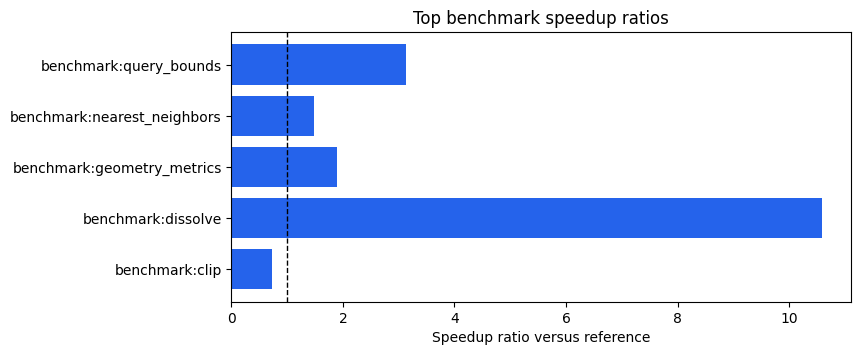

In [3]:
import matplotlib.pyplot as plt

rows = [row for row in summary][:5]
labels = [f"{row['dataset']}:{row['operation']}" for row in rows]
ratios = [row['speedup_ratio'] for row in rows]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(labels, ratios, color='#2563eb')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Top benchmark speedup ratios')
ax.set_xlabel('Speedup ratio versus reference')
plt.show()